In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pyprojroot import here

latent_dim = 20
n_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose(
    [

        transforms.ToTensor(),

    ]
)

mnist_train = datasets.MNIST(
    root=here("data"), train=True, download=True, transform=transform
)

mnist_test = datasets.MNIST(
    root=here("data"), train=False, download=True, transform=transform
)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)

test_loader = DataLoader(mnist_test, batch_size=2, shuffle=True)

In [ ]:
class cVAE(nn.Module):
    def __init__(self, latent_dim=20, n_classes=10):
        super(cVAE, self).__init__()
        self.latent_dim = latent_dim
        self.n_classes = n_classes
        # encoder (input image and one-hot encoded label)
        self.enc_fc1 = nn.Linear(28 * 28 + n_classes, 400)
        self.enc_fc2_mu = nn.Linear(400, latent_dim)
        self.enc_fc2_logvar = nn.Linear(400, latent_dim)
        # decoder(input is latent abd one-hot encoded label)
        self.dec_fc1 = nn.Linear(latent_dim + n_classes, 400)
        self.dec_fc2 = nn.Linear(400, 28 * 28)

    def encoder(self, x, y):
        # x: [batch, 1, 28, 28], y: [batch, n_classes]
        x = x.view(-1, 28 * 28)
        h = torch.cat([x, y], dim=1)
        h1 = F.relu(self.enc_fc1(h))
        mu = self.enc_fc2_mu(h1)
        logvar = self.enc_fc2_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decoder(self, z, y):
        # z: [batch, latent_dim], y: [batch, n_classes]
        h = torch.cat([z, y], dim=1)
        h3 = F.relu(self.dec_fc1(h))
        return torch.sigmoid(self.dec_fc2(h3)).view(-1, 28, 28)

    def forward(self, x, y):
        mu, logvar = self.encoder(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z, y), mu, logvar

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    recon_x = recon_x.view(-1, 28 * 28)
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28 * 28), reduction="sum")
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [5]:
def train(model, train_loader, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for data, targets in train_loader:
            data = data.to(device)
            y = F.one_hot(targets, num_classes=n_classes).float().to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data, y)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {train_loss / len(train_loader.dataset):.4f}")
    model.eval()

In [6]:
# Model
model = cVAE(latent_dim=latent_dim, n_classes=n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
train(model, train_loader, optimizer, epochs=5)

Epoch 1, Loss: 161.7766
Epoch 2, Loss: 119.2745
Epoch 3, Loss: 112.2223
Epoch 4, Loss: 108.9428
Epoch 5, Loss: 106.9676


# Test (cVAE)

## Conditional Generation Test

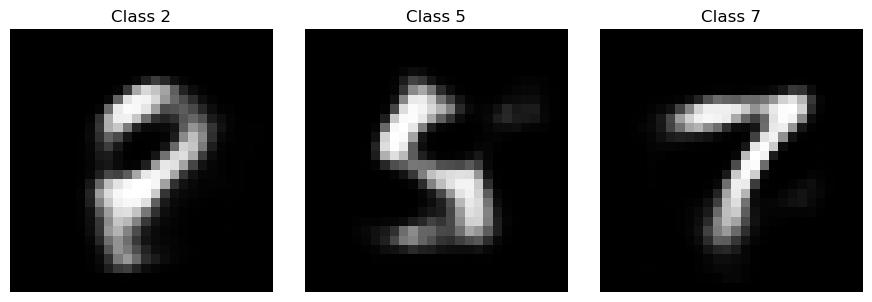

In [ ]:
import torch.nn.functional as F

latent_dim = model.latent_dim
device = next(model.parameters()).device

# Choose three different classes (e.g., 2, 5, 7)
class_indices = [2, 5, 7]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i, class_idx in enumerate(class_indices):
    # Sample random latent vector
    z = torch.randn(1, latent_dim).to(device)
    # Create one-hot label
    y = (
        F.one_hot(torch.tensor([class_idx]), num_classes=model.n_classes)
        .float()
        .to(device)
    )
    # Generate image
    with torch.no_grad():
        generated_img = model.decoder(z, y).cpu().squeeze().numpy()
    axes[i].imshow(generated_img, cmap="gray")
    axes[i].set_title(f"Class {class_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Reconstruction Test

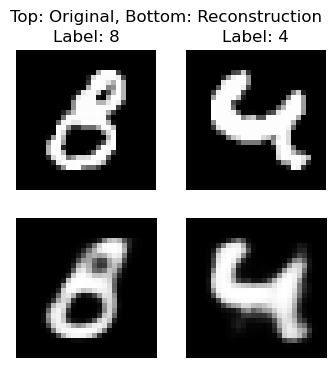

In [ ]:
def test_reconstruction(model, test_loader, n_classes=10, device="cpu", num_images=8):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images.to(device)
    labels = labels.to(device)
    y = F.one_hot(labels, num_classes=n_classes).float().to(device)

    with torch.no_grad():
        recon_images, _, _ = model(images, y)

    plt.figure(figsize=(2 * num_images, 4))
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
        # Reconstruction
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(recon_images[i].cpu().squeeze(), cmap="gray")
        plt.axis("off")
    plt.suptitle("Top: Original, Bottom: Reconstruction")
    plt.show()


test_reconstruction(
    model, test_loader, n_classes=n_classes, device=device, num_images=2
)